<a href="https://colab.research.google.com/github/zohrehasadi00/automatic_image_analysis/blob/main/notebooks/Classical_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamental setup

In [1]:
# import collection

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import cv2

from scipy.sparse import find

In [3]:
#set seed for reproducibility
random_state = 42
torch.manual_seed(random_state)
np.random.seed(random_state)


In [4]:
# connect Drive for data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# set project_dir
project_dir = Path('.') / 'drive' / 'MyDrive' / 'AIA_SkinLesion_Projekt'

In [6]:
#path to image data
data_raw =[
    str(project_dir / 'data' / 'raw' / 'HAM10000_images_part_1'),
    str(project_dir / 'data' / 'raw' / 'HAM10000_images_part_2')
    ]

# load metadata
csv_path = project_dir / 'HAM10000_metadata_converted.csv'
df_metadata = pd.read_csv(csv_path)

#load splits
csv_train = project_dir / 'splits' / 'train.csv'
df_train = pd.read_csv(csv_train)

csv_test = project_dir / 'splits' / 'test.csv'
df_test = pd.read_csv(csv_test)

csv_val = project_dir / 'splits' / 'val.csv'
df_val = pd.read_csv(csv_val)

#load histogram
feature_dir = project_dir / 'histogram'

#Train-Set laden
X_train = np.load(os.path.join(feature_dir, 'train_histograms.npy'))
y_train = np.load(os.path.join(feature_dir, 'train_labels.npy'))
ids_train = np.load(os.path.join(feature_dir, 'train_ids.npy'))

#Validation-Set laden
X_val = np.load(os.path.join(feature_dir, 'val_histograms.npy'))
y_val = np.load(os.path.join(feature_dir, 'val_labels.npy'))
ids_val = np.load(os.path.join(feature_dir, 'val_ids.npy'))

#Test-Set laden
X_test = np.load(os.path.join(feature_dir, 'test_histograms.npy'))
y_test = np.load(os.path.join(feature_dir, 'test_labels.npy'))
ids_test = np.load(os.path.join(feature_dir, 'test_ids.npy'))

# Data preprocessing for classical pipeline

In [ ]:
# define image tranformations for train and test/validation set
train_transforms_classical = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

test_transforms_classical = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

## function for searching images from drive
def find_image_path(img_id, directories):
    img_name = img_id + '.jpg'
    for directory in directories:
        path = os.path.join(directory, img_name)
        if os.path.exists(path):
            return path
    return None

# Dataset class
class SkinDataset(Dataset):
    def __init__(self, dataframe, img_dirs, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dirs = img_dirs
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.loc[idx, 'image_id']
        img_name = img_id + '.jpg'
        img_path = None

        # search in both folders (part 1&2) for the image
        img_path = find_image_path(img_id, self.img_dirs)

        if img_path is None:
            raise FileNotFoundError(f"Image {img_name} not found!")

        image = Image.open(img_path).convert('RGB')
        label = self.data.loc[idx, 'label']

        if self.transform:
            image = self.transform(image)

        # PyTorch expects labels as Float for binary loss (BCEWithLogitsLoss)
        return image, torch.tensor(label, dtype=torch.float32), img_id



# create data sets
train_dataset = SkinDataset(df_train, data_raw, transform=train_transforms_classical)
val_dataset = SkinDataset(df_val, data_raw, transform=test_transforms_classical)
test_dataset = SkinDataset(df_test, data_raw, transform=test_transforms_classical)

In [ ]:
## convert RGB to HSV
def tensor_to_hsv(tensor):
    # Tensor (3, H, W) → NumPy (H, W, 3) in RGB
    img_np = tensor.numpy().transpose(1, 2, 0)
    img_uint8 = (img_np * 255).astype(np.uint8)

    # RGB → HSV
    img_hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)
    return img_hsv  # shape: (H, W, 3), values: H[0-179], S[0-255], V[0-255]

def compute_hsv_histogram(img_hsv, bins=32):
    hist_h = cv2.calcHist([img_hsv], [0], None, [bins], [0, 180])
    hist_s = cv2.calcHist([img_hsv], [1], None, [bins], [0, 256])
    hist_v = cv2.calcHist([img_hsv], [2], None, [bins], [0, 256])

    # normalize and flatten -> one feature-vector per image
    hist = np.concatenate([hist_h, hist_s, hist_v], axis=0).flatten()
    return hist / hist.sum()

## function for plotting a HSV-histogram from a single image
def plot_hsv_histogram(hist, bins=32):

    #as compute_hsv_histograms return an array with shape (96,) this must be split into 3 channels
    hist_h = hist[:bins]
    hist_s = hist[bins:bins*2]
    hist_v = hist[bins*2:]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, h, name, color in zip(axes,
                                   [hist_h, hist_s, hist_v],
                                   ['Hue', 'Saturation', 'Value'],
                                   ['red', 'blue', 'gray']):
        ax.bar(range(bins), h, color=color, alpha=0.7)
        ax.set_title(name)
        ax.set_xlabel('bin')
        ax.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()




img id ISIC_0032524


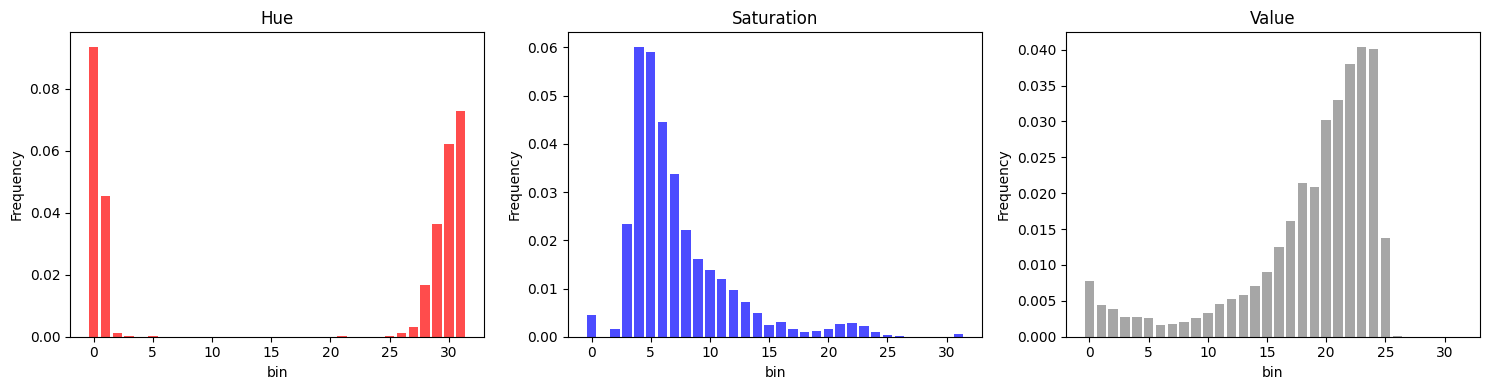

In [ ]:
#example histogram

image, label, img_id = train_dataset[42]
img_hsv = tensor_to_hsv(image)
hist = compute_hsv_histogram(img_hsv)
print(f"img id {img_id}")
plot_hsv_histogram(hist)


In [ ]:
#compute all histograms
# all_histograms = []
# all_labels = []

#calculate histogram for each image from training data
# for idx in range(len(train_dataset)):
#     if idx%1000 == 0: print(idx)
#     image, label, img_id = train_dataset[idx]
#     img_hsv = tensor_to_hsv(image)
#     hist = compute_hsv_histogram(img_hsv)
#     all_histograms.append(hist)
#     all_labels.append(label.item())

# all_histograms = np.array(all_histograms)
# all_labels = np.array(all_labels)

# new histogram dir
feature_dir = project_dir / 'histogram'
os.makedirs(feature_dir, exist_ok=True)

def extract_and_save_features(dataset, split_name):
    print(f"start {split_name} (in total {len(dataset)} img)...")

    histograms = []
    labels = []
    img_ids = []

    for idx in range(len(dataset)):
        if idx % 1000 == 0 and idx > 0:
            print(f"  ... {idx} img.")

        image, label, img_id = dataset[idx]

        img_hsv = tensor_to_hsv(image)
        hist = compute_hsv_histogram(img_hsv)

        histograms.append(hist)
        labels.append(label.item())
        img_ids.append(img_id)

    histograms = np.array(histograms)
    labels = np.array(labels)
    img_ids = np.array(img_ids)

    np.save(os.path.join(feature_dir, f'{split_name}_histograms.npy'), histograms)
    np.save(os.path.join(feature_dir, f'{split_name}_labels.npy'), labels)
    np.save(os.path.join(feature_dir, f'{split_name}_ids.npy'), img_ids) # <--- NEU

    print(f"✅ {split_name} saved!\n")

extract_and_save_features(train_dataset, "train")
extract_and_save_features(val_dataset, "val")
extract_and_save_features(test_dataset, "test")

start train (in total 7010 img)...
  ... 1000 img.
  ... 2000 img.
  ... 3000 img.
  ... 4000 img.
  ... 5000 img.
  ... 6000 img.
  ... 7000 img.
✅ train saved!

start val (in total 1002 img)...
  ... 1000 img.
✅ val saved!

start test (in total 2003 img)...
  ... 1000 img.
  ... 2000 img.
✅ test saved!



--- data controle ---
shape histogram: (7010, 96)
shape label:      (7010,)
shape id:         (7010,)

--- sample (first img) ---
img id:    ISIC_0033409
label:   0.0 (0 = benign, 1 = mel)
color values: [7.1614585e-03 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 1.9929847e-05 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 6.6432822e-06 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 6.6432822e-06 0.0000000e+00 2.6573129e-05 0.0000000e+00
 0.0000000e+00 1.1891476e-03 1.9929848e-04 4.8495960e-04 3.7800276e-03
 3.9912838e-02 1.0131670e-01 1.3568904e-01 3.0412946e-02 2.5842369e-03
 5.3345556e-03 5.2083335e-03 6.3841944e-03 0.0000000e+00 0.0000000e+00
 1.9996280e-03 8.4542409e-02 8.3831578e-02 5.1485438e-02 2.8645834e-02
 1.4655081e-02 8.3041033e-03 5.9789540e-03 5.0090346e-03 4.2051976e-03
 3.5740859e-03 3.8331740e-03 3.4810798e-03 6.7562182e-03 3.9394666e-03
 2.7835353e-03 3.0359800e-03 1.2688669e-03 3.0293367e-03 3.1289859e-03
 2.8233950e-03 3

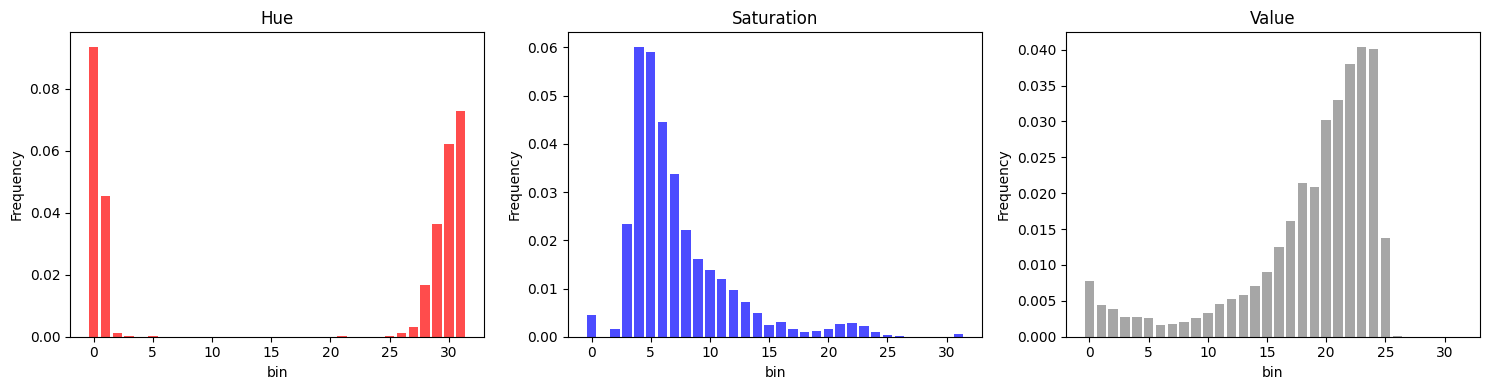

In [ ]:
print("--- data controle ---")
print(f"shape histogram: {X_train.shape}")
print(f"shape label:      {y_train.shape}")
print(f"shape id:         {ids_train.shape}")

print("\n--- sample (first img) ---")
print(f"img id:    {ids_train[0]}")
print(f"label:   {y_train[0]} (0 = benign, 1 = mel)")
print(f"color values: {X_train[0][:96]} ...")

# --- Exact Lookup Sanity Check ---

def verify_lookup(df_csv, ids_npy, labels_npy, split_name):
    # 1. Make CSV easily searchable (set 'image_id' as the index)
    csv_lookup = df_csv.set_index('image_id')['label']

    # 2. Take IDs from NPY data and look up their corresponding labels in the CSV
    found_csv_labels = pd.Series(ids_npy).map(csv_lookup)

    # 3. Compare original NPY labels with the labels found in the CSV
    errors = (labels_npy != found_csv_labels).sum()

    # 4. Print status
    status = "✅ PERFECT" if errors == 0 else f"❌ {errors} ERRORS"
    print(f"{split_name:<12} | Checked: {len(ids_npy):<5} | Status: {status}")

# Run the explicit lookup check for all splits
verify_lookup(df_train, ids_train, y_train, "Train")
verify_lookup(df_val, ids_val, y_val, "Validation")
verify_lookup(df_test, ids_test, y_test, "Test")

print(f"img id:    {ids_train[42]}")
print(f"label:   {y_train[42]} (0 = benign, 1 = mel)")
plot_hsv_histogram(X_train[42])

#GMM with EM

Number of benign samples for training:   6231
Number of melanoma samples for training: 779
 Training arc

Training GMM for benign samples with K=1 components...
Training GMM for melanoma samples with K=1 components...

Training GMM for benign samples with K=2 components...
Training GMM for melanoma samples with K=2 components...

Training GMM for benign samples with K=3 components...
Training GMM for melanoma samples with K=3 components...

Training GMM for benign samples with K=4 components...
Training GMM for melanoma samples with K=4 components...

Training GMM for benign samples with K=5 components...
Training GMM for melanoma samples with K=5 components...

Training GMM for benign samples with K=6 components...
Training GMM for melanoma samples with K=6 components...

Training GMM for benign samples with K=7 components...
Training GMM for melanoma samples with K=7 components...

Training GMM for benign samples with K=8 components...
Training GMM for melanoma samples with K=8 compo

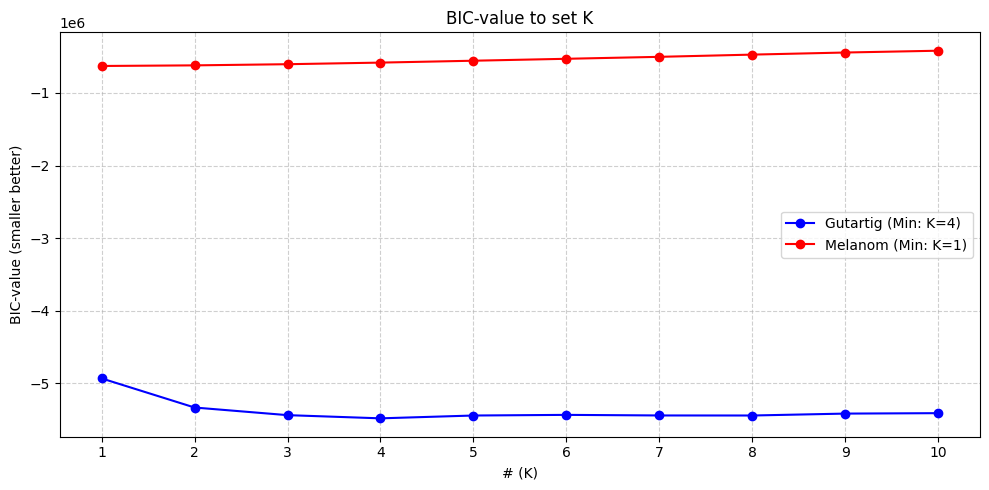

In [12]:
X_train_benign = X_train[y_train == 0]
X_train_melanoma = X_train[y_train == 1]

print(f"Number of benign samples for training:   {X_train_benign.shape[0]}")
print(f"Number of melanoma samples for training: {X_train_melanoma.shape[0]}")

print(" Training arc")

bic_melanoma = []
bic_benign = []

K_range = range(1, 11)

for K in K_range:
    print(f"\nTraining GMM for benign samples with K={K} components...")
    gmm_benign = GaussianMixture(n_components=K, random_state=random_state, covariance_type='full') # 'full', 'tied', 'diag', 'spherical'
    gmm_benign.fit(X_train_benign) #fit = EM
    bic_benign.append(gmm_benign.bic(X_train_benign))
    # print(f"  Converged: {gmm_benign.converged_}")
    # print(f"  BIC: {bic_benign[K-1]:.2f}")
    # print(f"  AIC: {gmm_benign.aic(X_train_benign):.2f}")

    print(f"Training GMM for melanoma samples with K={K} components...")
    gmm_melanoma = GaussianMixture(n_components=K, random_state=random_state, covariance_type='full')
    gmm_melanoma.fit(X_train_melanoma)
    bic_melanoma.append(gmm_melanoma.bic(X_train_melanoma))
    # print(f"  Converged: {gmm_melanoma.converged_}")
    # print(f"  BIC: {bic_melanoma[K-1]:.2f}")
    # print(f"  AIC: {gmm_melanoma.aic(X_train_melanoma):.2f}")

min_K_benign = np.argmin(bic_benign) + 1
min_K_melanoma = np.argmin(bic_melanoma) + 1

print(f"Opt K for benign: {min_K_benign}")
print(f"Opt K for Melanom:  {min_K_melanoma}")

print("trianig done")

plt.figure(figsize=(10, 5))

# Plot for benign
plt.plot(K_range, bic_benign, marker='o', color='blue', label=f'Gutartig (Min: K={min_K_benign})')

# Plot for melanom
plt.plot(K_range, bic_melanoma, marker='o', color='red', label=f'Melanom (Min: K={min_K_melanoma})')

plt.title('BIC-value to set K')
plt.xlabel('# (K)')
plt.ylabel('BIC-value (smaller better)')
plt.xticks(K_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()